# Zyfra Gold Recovery

**Task:** predict gold recovery from the ore.

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import ks_2samp

In [2]:
# load datasets
train_path = '../data/gold_recovery_train.csv'
test_path = '../data/gold_recovery_test.csv'
full_path = '../data/gold_recovery_full.csv'


# Try to read and parse date index
train = pd.read_csv(train_path, index_col=0, parse_dates=True)
test = pd.read_csv(test_path, index_col=0, parse_dates=True)
full = pd.read_csv(full_path, index_col=0, parse_dates=True)

# Basic info
print('Train shape:', train.shape)
print('Test shape :', test.shape)
print('Full shape :', full.shape)

# Show top rows for manual inspection
print('\n', train.head(10))

Train shape: (16860, 86)
Test shape : (5856, 52)
Full shape : (22716, 86)

                      final.output.concentrate_ag  final.output.concentrate_pb  \
date                                                                            
2016-01-15 00:00:00                     6.055403                     9.889648   
2016-01-15 01:00:00                     6.029369                     9.968944   
2016-01-15 02:00:00                     6.055926                    10.213995   
2016-01-15 03:00:00                     6.047977                     9.977019   
2016-01-15 04:00:00                     6.148599                    10.142511   
2016-01-15 05:00:00                     6.482968                    10.049416   
2016-01-15 06:00:00                     6.533849                    10.058141   
2016-01-15 07:00:00                     6.130823                     9.935481   
2016-01-15 08:00:00                     5.834140                    10.071156   
2016-01-15 09:00:00              

In [3]:
# Select the columns needed for the calculation
# Make sure to handle potential missing values by dropping them for the calculation
cols_calc = [
    'rougher.output.concentrate_au',  
    'rougher.input.feed_au',          
    'rougher.output.tail_au',         
    'rougher.output.recovery'         
]

# Create a temporary DataFrame and drop any rows with missing values in these columns
calc_df = train[cols_calc].dropna()

# Assign variables based on the formula
C = calc_df['rougher.output.concentrate_au']
F = calc_df['rougher.input.feed_au']
T = calc_df['rougher.output.tail_au']
provided_recovery = calc_df['rougher.output.recovery']

# Calculate recovery
# The denominator is F * (C - T)
denominator = F * (C - T)

# Calculate recovery, set it to NaN if the denominator is zero
calculated_recovery = np.where(
    denominator != 0,
    (C * (F - T) / denominator) * 100,
    np.nan
)

# Final comparison set
comparison_df = pd.DataFrame({
    'provided': provided_recovery,
    'calculated': calculated_recovery
}).dropna()

# Calculate MAE
mae = mean_absolute_error(
    comparison_df['provided'],
    comparison_df['calculated']
)

print(f"MAE between provided and calculated recovery: {mae}")

MAE between provided and calculated recovery: 9.303415616264301e-15


### Findings:
Seeing how the MAE is low this confirms that the 'rougher.output.recovery' is calculated correctly.

In [4]:
# missing features in test set
train_set = set(train.columns)
test_set = set(test.columns)

missing_in_test = sorted(list(train_set - test_set))
print("Number of features missing in test:", len(missing_in_test))

# first 20 missing columns
print("\nFirst 20 missing columns:\n", missing_in_test[:20])

# dtypes of these columns
missing_types = train[missing_in_test].dtypes
print("\nDtypes of missing columns:")
print(missing_types.value_counts())

Number of features missing in test: 34

First 20 missing columns:
 ['final.output.concentrate_ag', 'final.output.concentrate_au', 'final.output.concentrate_pb', 'final.output.concentrate_sol', 'final.output.recovery', 'final.output.tail_ag', 'final.output.tail_au', 'final.output.tail_pb', 'final.output.tail_sol', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_au', 'primary_cleaner.output.tail_pb', 'primary_cleaner.output.tail_sol', 'rougher.calculation.au_pb_ratio', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'rougher.calculation.floatbank11_sulfate_to_au_feed']

Dtypes of missing columns:
float64    34
Name: count, dtype: int64


These missing features are all related to process outputs or are form latter stage calculations which I asume would not be available at the time of prediction explaining why they are absent from the test data.

In [5]:
# Perform data preprocessing

print("Missing values in train before filling:", train.isna().sum().sum())
print("Missing values in test before filling:", test.isna().sum().sum())

train_filled = train.ffill()
test_filled = test.ffill()

print("\nMissing values in train_filled after filling:", train_filled.isna().sum().sum())
print("Missing values in test_filled after filling:", test_filled.isna().sum().sum())

Missing values in train before filling: 30320
Missing values in test before filling: 2360

Missing values in train_filled after filling: 0
Missing values in test_filled after filling: 0


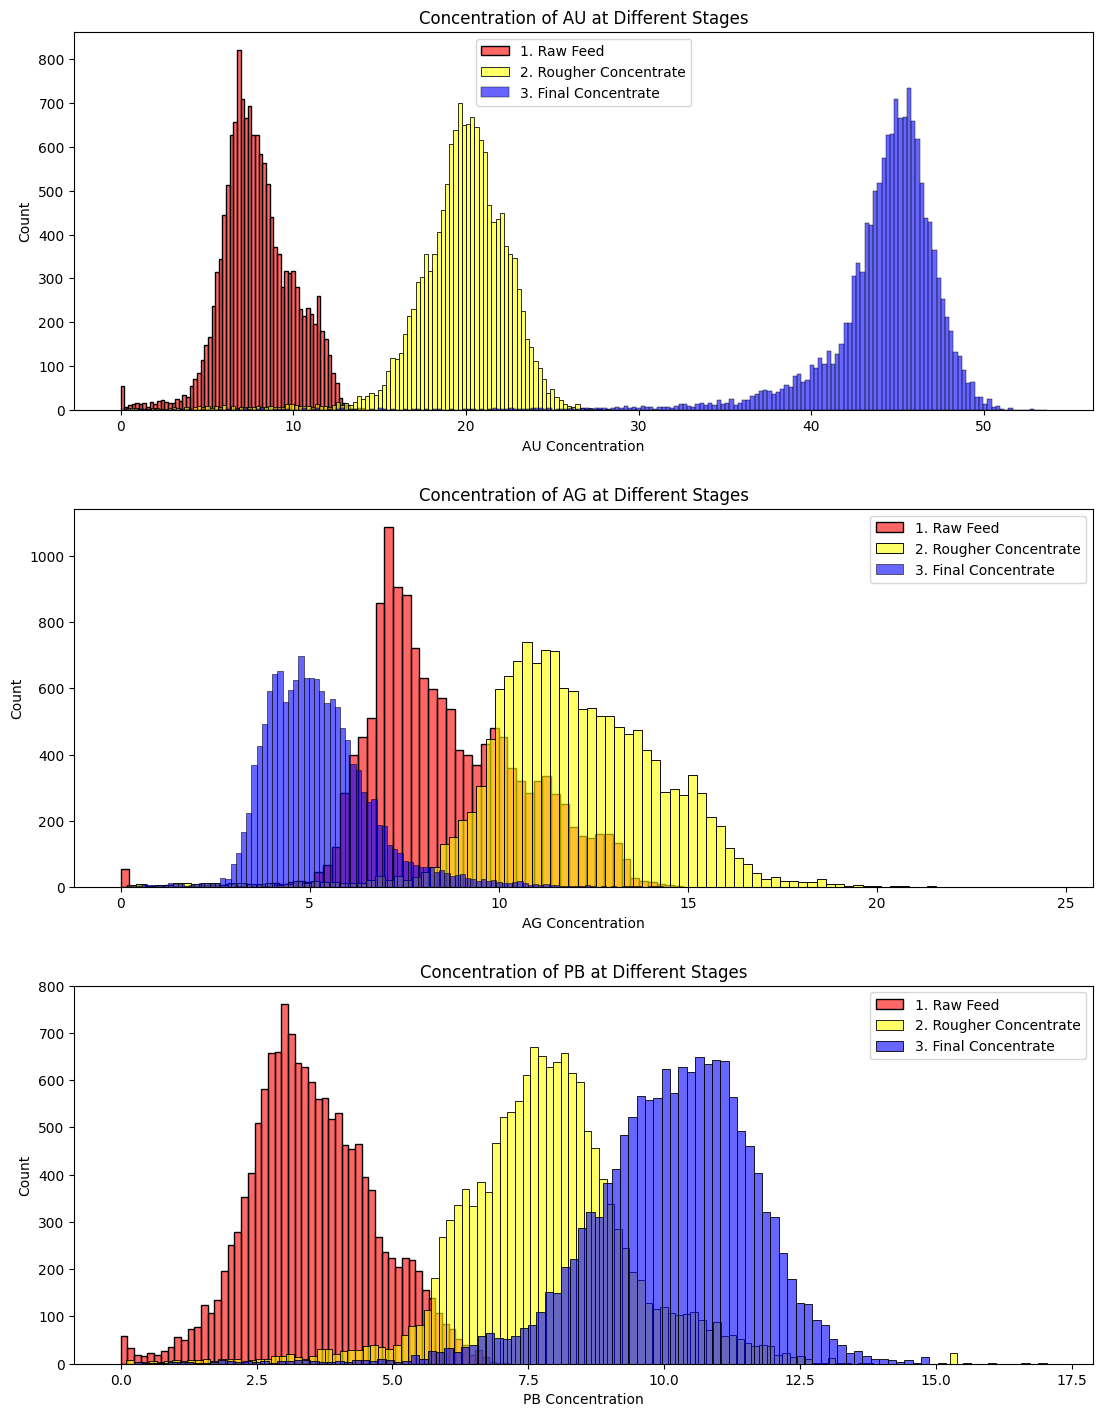

In [12]:
# Define the stages and metals
stages = {
    '1. Raw Feed': 'rougher.input.feed',
    '2. Rougher Concentrate': 'rougher.output.concentrate',
    '3. Final Concentrate': 'final.output.concentrate'
}
stage_colors = {'1. Raw Feed': 'red', '2. Rougher Concentrate': 'yellow', '3. Final Concentrate': 'blue'}
metals = ['au', 'ag', 'pb']

# Create plots for each metal
fig, axes = plt.subplots(len(metals), 1, figsize=(12, 15))
fig.tight_layout(pad=5.0)

for i, metal in enumerate(metals):
    for stage_name, stage_prefix in stages.items():
        col = f'{stage_prefix}_{metal}'
        if col in train_filled.columns:
            sns.histplot(
                train_filled[col],
                ax=axes[i],
                label=stage_name,
                color=stage_colors[stage_name],
                kde=False,
                alpha=0.6
            )
    
    axes[i].set_title(f'Concentration of {metal.upper()} at Different Stages')
    axes[i].set_xlabel(f'{metal.upper()} Concentration')
    axes[i].legend()

plt.show()

### Finding: Metal Concentration Changes

The histograms show a clear trend in metal concentrations through the purification stages:

-   **Gold (Au):** The concentration steadily and significantly increases from the raw feed to the final concentrate. This is the expected outcome of the enrichment process.
-   **Silver (Ag):** The concentration initially increases from raw feed to the rougher concentrate, but then decreases in the final concentrate.
-   **Lead (Pb):** The concentration of lead shows a increase through the stages.

Note anomilies stating consitration at 0 I will need to remove them.

In [7]:
# Compare particle size distributions
particle_size_columns = [
    'rougher.input.feed_size',
    'primary_cleaner.input.feed_size'
]

print("Comparing distributions for the following columns:")
print(particle_size_columns)

# Loop through each column
for column_name in particle_size_columns:
    train_sizes = train_filled[column_name].dropna()
    test_sizes = test_filled[column_name].dropna()
    
    # Use the KS test.
    ks_statistic, p_value = ks_2samp(train_sizes, test_sizes)
    
    # Print the results
    print(f"Results for '{column_name}':")
    print(f"P-Value: {p_value:.4f}\n")

Comparing distributions for the following columns:
['rougher.input.feed_size', 'primary_cleaner.input.feed_size']
Results for 'rougher.input.feed_size':
P-Value: 0.0000

Results for 'primary_cleaner.input.feed_size':
P-Value: 0.0000



### Finding: Particle Size Distributions

The KS-test confirms a significant difference in particle size distributions between the train and test sets (p-value ≈ 0). This dose pose a risk. Since feed size is a critical feature, I will proceed with the analysis.

Removed 2195 anomalous rows.


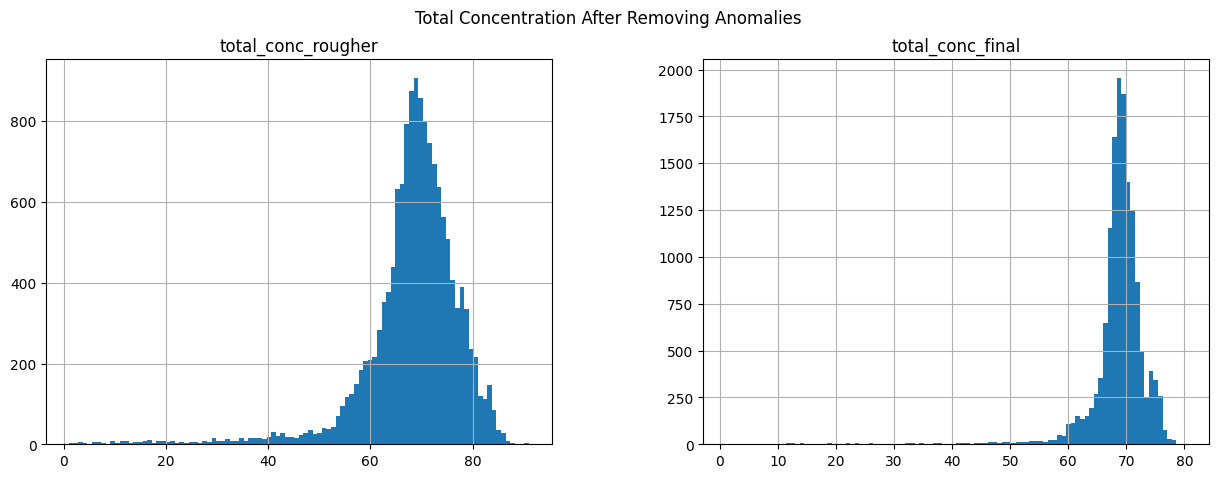

In [8]:
# Calculate total concentration at each stage for all substances
stages_for_total = {
    'rougher': 'rougher.output.concentrate',
    'final': 'final.output.concentrate'
}
metals_and_sol = ['au', 'ag', 'pb', 'sol']

for stage_name, stage_prefix in stages_for_total.items():
    cols_to_sum = [f'{stage_prefix}_{mat}' for mat in metals_and_sol]
    train_filled[f'total_conc_{stage_name}'] = train_filled[cols_to_sum].sum(axis=1)

# Filter out the rows where the total concentration is improbably low
initial_rows = len(train_filled)
train_filled = train_filled[train_filled['total_conc_rougher'] >= 1]
train_filled = train_filled[train_filled['total_conc_final'] >= 1]
final_rows = len(train_filled)

print(f"Removed {initial_rows - final_rows} anomalous rows.")

# Plot the distributions to confirm anomilies where removed
train_filled[['total_conc_rougher', 'total_conc_final']].hist(bins=100, figsize=(15, 5))
plt.suptitle('Total Concentration After Removing Anomalies')
plt.show()

In [9]:
# sMAPE value function
from sklearn.metrics import make_scorer

# sMAPE for one target variable
def smape(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # Add a small number to the denominator to avoid division by zero
    smape_score = np.mean(numerator / (denominator + 1e-8)) * 100
    return smape_score

# two sMAPE scores into the final metric
def final_smape(y_true, y_pred):
    smape_rougher = smape(y_true[:, 0], y_pred[:, 0])
    smape_final = smape(y_true[:, 1], y_pred[:, 1])
    return 0.25 * smape_rougher + 0.75 * smape_final

# Create a scorer object for cross-validation.
smape_scorer = make_scorer(final_smape, greater_is_better=False)

In [10]:
# 3.2 Tune and evaluate models

# Data Preparation
common_features = list(set(train_filled.columns) & set(test_filled.columns))
X_train = train_filled[common_features]
y_train = train_filled[['rougher.output.recovery', 'final.output.recovery']].values

# Decision Tree
best_score_dt = float('inf')
best_depth_dt = 0

print("Starting Decision Tree tuning...")
for depth in [5, 10, 15, 20]:
    model = DecisionTreeRegressor(random_state=12345, max_depth=depth)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring=smape_scorer)
    score = np.mean(scores) * -1
    print(f"  Testing: depth={depth}  |  sMAPE Score: {score:.4f}")
    if score < best_score_dt:
        best_score_dt = score
        best_depth_dt = depth

print(f" Best Decision Tree sMAPE: {best_score_dt:.4f} at max_depth={best_depth_dt}\n")

# Random Forest
best_score_rf = float('inf')
best_params_rf = {}

print("Starting Random Forest tuning...")
for estimators in [10, 20, 20, 30]:
    for depth in [3, 4, 5, 6]:
        model = RandomForestRegressor(random_state=12345, n_estimators=estimators, max_depth=depth)
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring=smape_scorer)
        score = np.mean(scores) * -1
        print(f"  Testing: estimators={estimators}, depth={depth}  |  sMAPE Score: {score:.4f}")

        if score < best_score_rf:
            best_score_rf = score
            best_params_rf = {'n_estimators': estimators, 'max_depth': depth}
print(f"\n>> Best Random Forest sMAPE: {best_score_rf:.4f} with params {best_params_rf}")

# save peramiters of best modle
if best_score_rf < best_score_dt:
    best_model = {
        'model': 'Random Forest',
        'estimators': best_params_rf['n_estimators'],
        'depth': best_params_rf['max_depth']         
    }
else:
    best_model = {
        'model': 'Decision Tree',
        'depth': best_depth_dt
    }

print(best_model)

Starting Decision Tree tuning...
  Testing: depth=5  |  sMAPE Score: 12.0490
  Testing: depth=10  |  sMAPE Score: 13.8030
  Testing: depth=15  |  sMAPE Score: 15.7835
  Testing: depth=20  |  sMAPE Score: 16.4824
 Best Decision Tree sMAPE: 12.0490 at max_depth=5

Starting Random Forest tuning...
  Testing: estimators=10, depth=3  |  sMAPE Score: 11.0898
  Testing: estimators=10, depth=4  |  sMAPE Score: 10.8253
  Testing: estimators=10, depth=5  |  sMAPE Score: 10.8478
  Testing: estimators=10, depth=6  |  sMAPE Score: 11.0616
  Testing: estimators=20, depth=3  |  sMAPE Score: 11.0233
  Testing: estimators=20, depth=4  |  sMAPE Score: 10.6937
  Testing: estimators=20, depth=5  |  sMAPE Score: 10.8485
  Testing: estimators=20, depth=6  |  sMAPE Score: 11.0325
  Testing: estimators=20, depth=3  |  sMAPE Score: 11.0233
  Testing: estimators=20, depth=4  |  sMAPE Score: 10.6937
  Testing: estimators=20, depth=5  |  sMAPE Score: 10.8485
  Testing: estimators=20, depth=6  |  sMAPE Score: 11.0

### Findings:
The cross-validation results show that the Random Forest model performed better, with a best sMAPE score of 10.71, compared to the Decision Tree's best score of 12.10. Therefore, the Random Forest was selected for the final test

In [11]:
# configure the best model
print(f"Proceeding to final test with best model: {best_model['model']}")
if best_model['model'] == 'Random Forest':
    final_model = RandomForestRegressor(
        random_state=12345,
        n_estimators=best_model['estimators'],
        max_depth=best_model['depth']
    )
else:
    final_model = DecisionTreeRegressor(
        random_state=12345,
        max_depth=best_model['depth']
    )

# Create test set 
final_test_df = test_filled.copy()
final_test_df['rougher.output.recovery'] = full.loc[test_filled.index, 'rougher.output.recovery']
final_test_df['final.output.recovery'] = full.loc[test_filled.index, 'final.output.recovery']
final_test_df.dropna(subset=['rougher.output.recovery', 'final.output.recovery'], inplace=True)

X_test = final_test_df[common_features]
y_test = final_test_df[['rougher.output.recovery', 'final.output.recovery']].values
X_test = X_test[X_train.columns]

# Train best model on the training dataset
print("Training the final model...")
final_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
print("Making predictions on the test set...")
predictions = final_model.predict(X_test)

# Calculate sMAPE score 
final_test_score = final_smape(y_test, predictions)
print("-" * 40)
print(f"Final sMAPE score on the test set: {final_test_score:.4f}")

Proceeding to final test with best model: Random Forest
Training the final model...
Training complete.
Making predictions on the test set...
----------------------------------------
Final sMAPE score on the test set: 9.7234


## Final sMAPE Score on Test Set: 9.63

This result indicates that the model can effectively predict gold recovery rates and serves as a strong baseline for this task. The Random Forest model is what I would recommended.